# DECISION TREE

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data Prepration

In [2]:
heart_df_orig = pd.read_excel('heart_disease.xlsx')

In [3]:
heart_df_orig.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


In [4]:
# Getting to know the data:
heart_df_orig.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


In [5]:
heart_df_orig['fbs'] =heart_df_orig['fbs'].astype('object')

In [6]:
heart_df_orig.describe()

,age,trestbps,chol,thalch,oldpeak,num
count,908.000000,908.000000,908.000000,908.000000,846.000000,908.000000
mean,53.791850,133.430617,201.484581,135.957048,0.891253,1.008811
std,9.158031,20.401608,112.097949,26.804929,1.093875,1.144436
min,29.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.750000,120.000000,176.750000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,224.000000,138.000000,0.500000,1.000000
75%,60.000000,144.000000,270.000000,156.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


In [7]:
heart_df_orig.duplicated().sum()

np.int64(1)

###### Summary
* 908 Rows, 13 columns
* There are null values in oldpeak column
* 1 Row is Duplicated
* 2 Columns with Boolean Values (one of which is stored as object)
* num Column is Response variable(Stages of heart disease, 0 if no heart disease); changing it to 0 or 1 for better model

In [8]:
heart_df_orig['num'] = np.where(heart_df_orig['num'] > 0, 1, heart_df_orig['num'])
heart_df_orig['num'].value_counts()

num
1    509
0    399
Name: count, dtype: int64

### Dropping Null Values

In [9]:
heart_df_orig.dropna(axis=0,inplace=True)

In [10]:
heart_df_orig.info()

<class 'pandas.core.frame.DataFrame'>
Index: 846 entries, 0 to 905
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       846 non-null    int64  
 1   sex       846 non-null    object 
 2   cp        846 non-null    object 
 3   trestbps  846 non-null    int64  
 4   chol      846 non-null    int64  
 5   fbs       846 non-null    object 
 6   restecg   846 non-null    object 
 7   thalch    846 non-null    int64  
 8   exang     846 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     846 non-null    object 
 11  thal      846 non-null    object 
 12  num       846 non-null    int64  
dtypes: float64(1), int64(5), object(7)
memory usage: 92.5+ KB


### Dropping Duplicated Rows

In [11]:
heart_df_orig.drop_duplicates(inplace=True)

In [12]:
heart_df_orig.duplicated().sum()

np.int64(0)

### Fixing dtypes

In [13]:
heart_df_orig.fbs.value_counts()

fbs
False    687
True     158
Name: count, dtype: int64

In [14]:
heart_df_orig.exang.value_counts()

exang
False    512
True     332
FALSE      1
Name: count, dtype: int64

In [15]:
# Dropping the row where the Value - 'FALSE'

heart_df_orig = heart_df_orig.drop(heart_df_orig[heart_df_orig['exang'] == 'FALSE'].index,axis=0)


In [16]:
heart_df_orig.exang.value_counts()


exang
False    512
True     332
Name: count, dtype: int64

In [17]:
heart_df = heart_df_orig.copy()

In [18]:
heart_df.num.value_counts()

num
1    467
0    377
Name: count, dtype: int64

# EDA

In [19]:
heart_df

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
901,51,Male,asymptomatic,110,0,True,normal,92,False,0.0,flat,fixed defect,1
902,62,Male,asymptomatic,160,254,True,st-t abnormality,108,True,3.0,flat,normal,1
903,53,Male,asymptomatic,125,0,False,normal,120,False,1.5,upsloping,reversable defect,1
904,62,Male,asymptomatic,166,170,False,st-t abnormality,120,True,3.0,flat,reversable defect,1


#### HISTOGRAMS

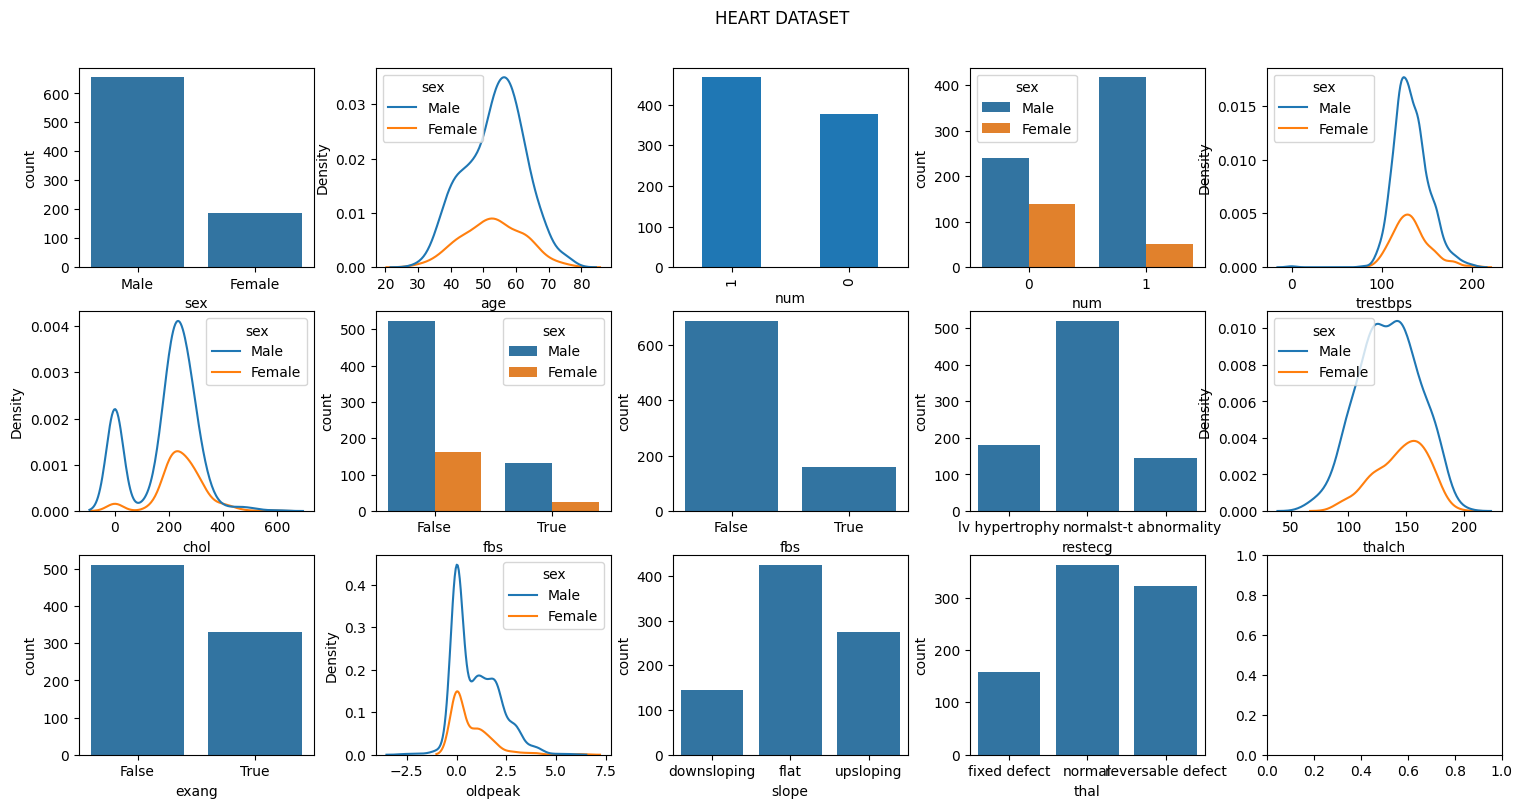

In [20]:
fig,axe = plt.subplots(3,5, figsize=(15,8))
plt.suptitle('HEART DATASET\n')
plt.tight_layout()
sns.countplot(data = heart_df, x='sex',ax=axe[0,0])
sns.kdeplot(data = heart_df,x='age',hue='sex',ax=axe[0,1]).set_xticks(np.arange(20, 90, 10))
heart_df['num'].value_counts().plot(kind='bar',ax=axe[0,2])
sns.countplot(data=heart_df,x='num',hue='sex',ax=axe[0,3])
sns.kdeplot(data=heart_df,x='trestbps',hue='sex',ax=axe[0,4])
sns.kdeplot(data=heart_df,x='chol',hue='sex',ax=axe[1,0])
sns.countplot(data=heart_df,x='fbs',ax=axe[1,1],hue='sex')
sns.countplot(data=heart_df,x='fbs',ax=axe[1,2])
sns.countplot(data=heart_df,x='restecg',ax=axe[1,3])
sns.kdeplot(data=heart_df,x='thalch',hue='sex',ax=axe[1,4])
sns.countplot(data=heart_df,x='exang',ax=axe[2,0])
sns.kdeplot(data=heart_df,x='oldpeak',hue='sex',ax=axe[2,1])
sns.countplot(data=heart_df,x='slope',ax=axe[2,2])
sns.countplot(data=heart_df,x='thal',ax=axe[2,3])

plt.show()

In [21]:
heart_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 844 entries, 0 to 905
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       844 non-null    int64  
 1   sex       844 non-null    object 
 2   cp        844 non-null    object 
 3   trestbps  844 non-null    int64  
 4   chol      844 non-null    int64  
 5   fbs       844 non-null    object 
 6   restecg   844 non-null    object 
 7   thalch    844 non-null    int64  
 8   exang     844 non-null    object 
 9   oldpeak   844 non-null    float64
 10  slope     844 non-null    object 
 11  thal      844 non-null    object 
 12  num       844 non-null    int64  
dtypes: float64(1), int64(5), object(7)
memory usage: 92.3+ KB


In [22]:
heart_df.nunique()

age          49
sex           2
cp            4
trestbps     63
chol        219
fbs           2
restecg       3
thalch      118
exang         2
oldpeak      53
slope         3
thal          3
num           2
dtype: int64


#### Boxplots

<Axes: xlabel='oldpeak'>

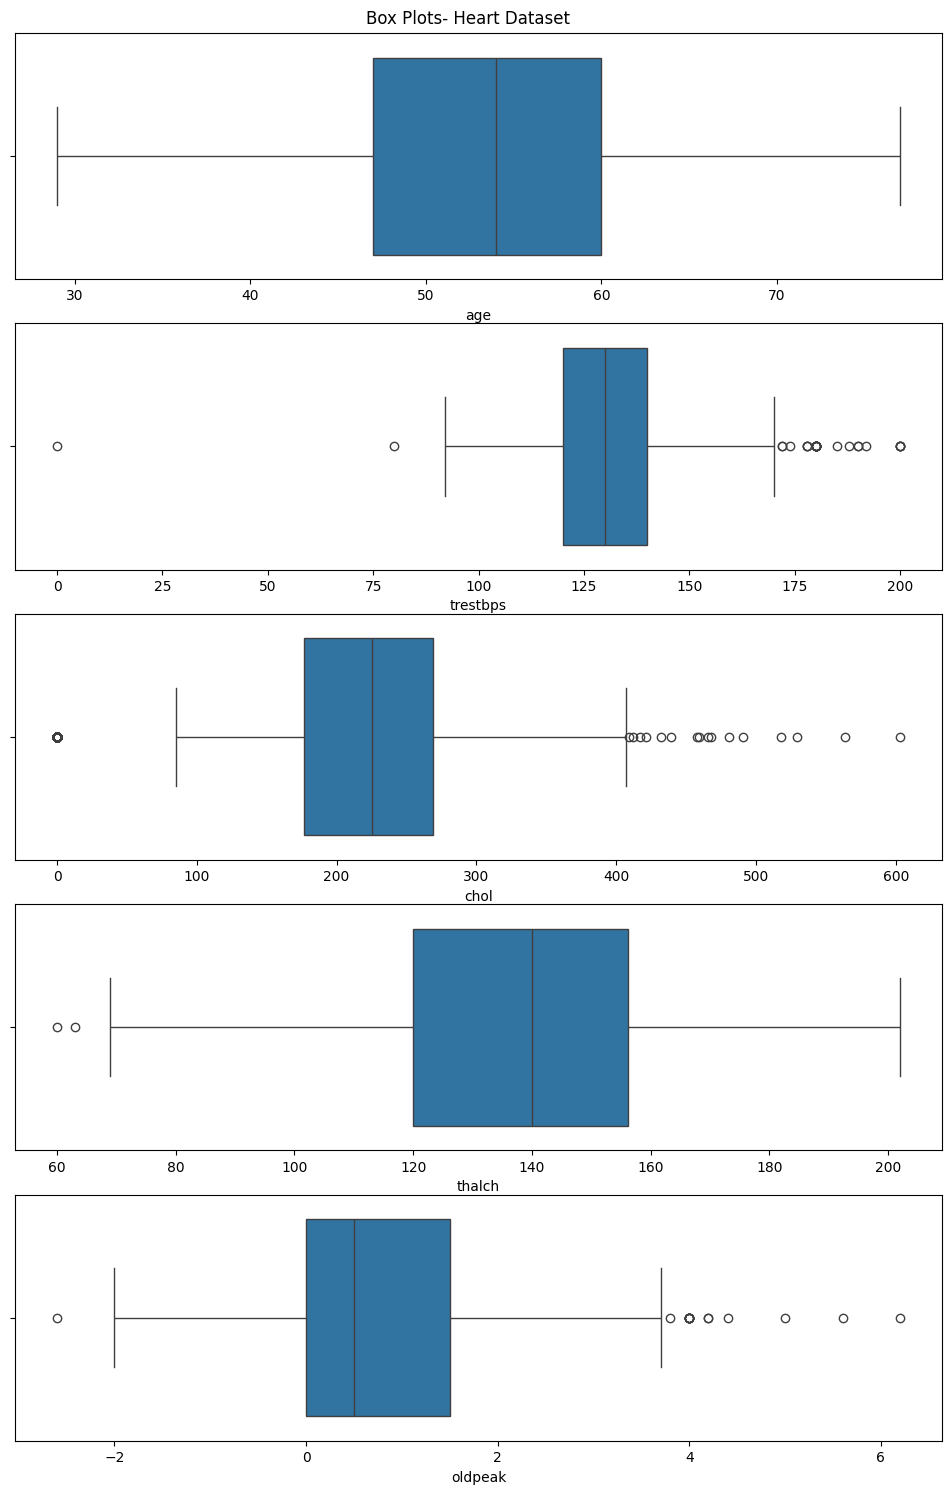

In [23]:
fig,axe2 = plt.subplots(5,1,figsize=(10,15))
plt.suptitle('Box Plots- Heart Dataset')
plt.tight_layout()
sns.boxplot(data=heart_df,x='age',ax=axe2[0])
sns.boxplot(data=heart_df,x='trestbps',ax=axe2[1])
sns.boxplot(data=heart_df,x='chol',ax=axe2[2])
sns.boxplot(data=heart_df,x='thalch',ax=axe2[3])
sns.boxplot(data=heart_df,x='oldpeak',ax=axe2[4])

#### Correlation Heatmap

<Axes: title={'center': 'Correlation matrix - Heatmap'}>

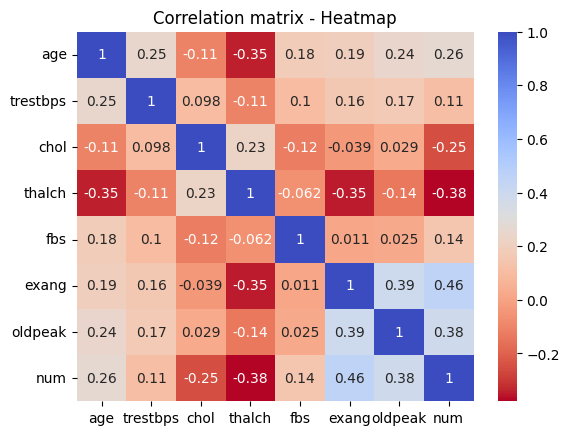

In [24]:
cols = ['age','trestbps','chol','thalch','fbs','exang','oldpeak','num']
subset = heart_df[cols]
plt.title('Correlation matrix - Heatmap')
sns.heatmap(subset.corr(),annot=True,cmap='coolwarm_r')

* Age is highly negatively correlated with maximum heart rate acheived(thalch).
* ST Depression and exercise linked Angina has highest Positive Correlation with stages of heart disease
* Maximum heart rate achieved (thalch) followed by cholesterol has lowest negative correlation with Stages of heart disease(num)
* Maximum heart rate achieved (thalch) is also highly correlated negatively with exercise induced angina (exang)
* ST Depression induced by exercise(oldpeak) is highly correlated with exercise induced angina (exang)

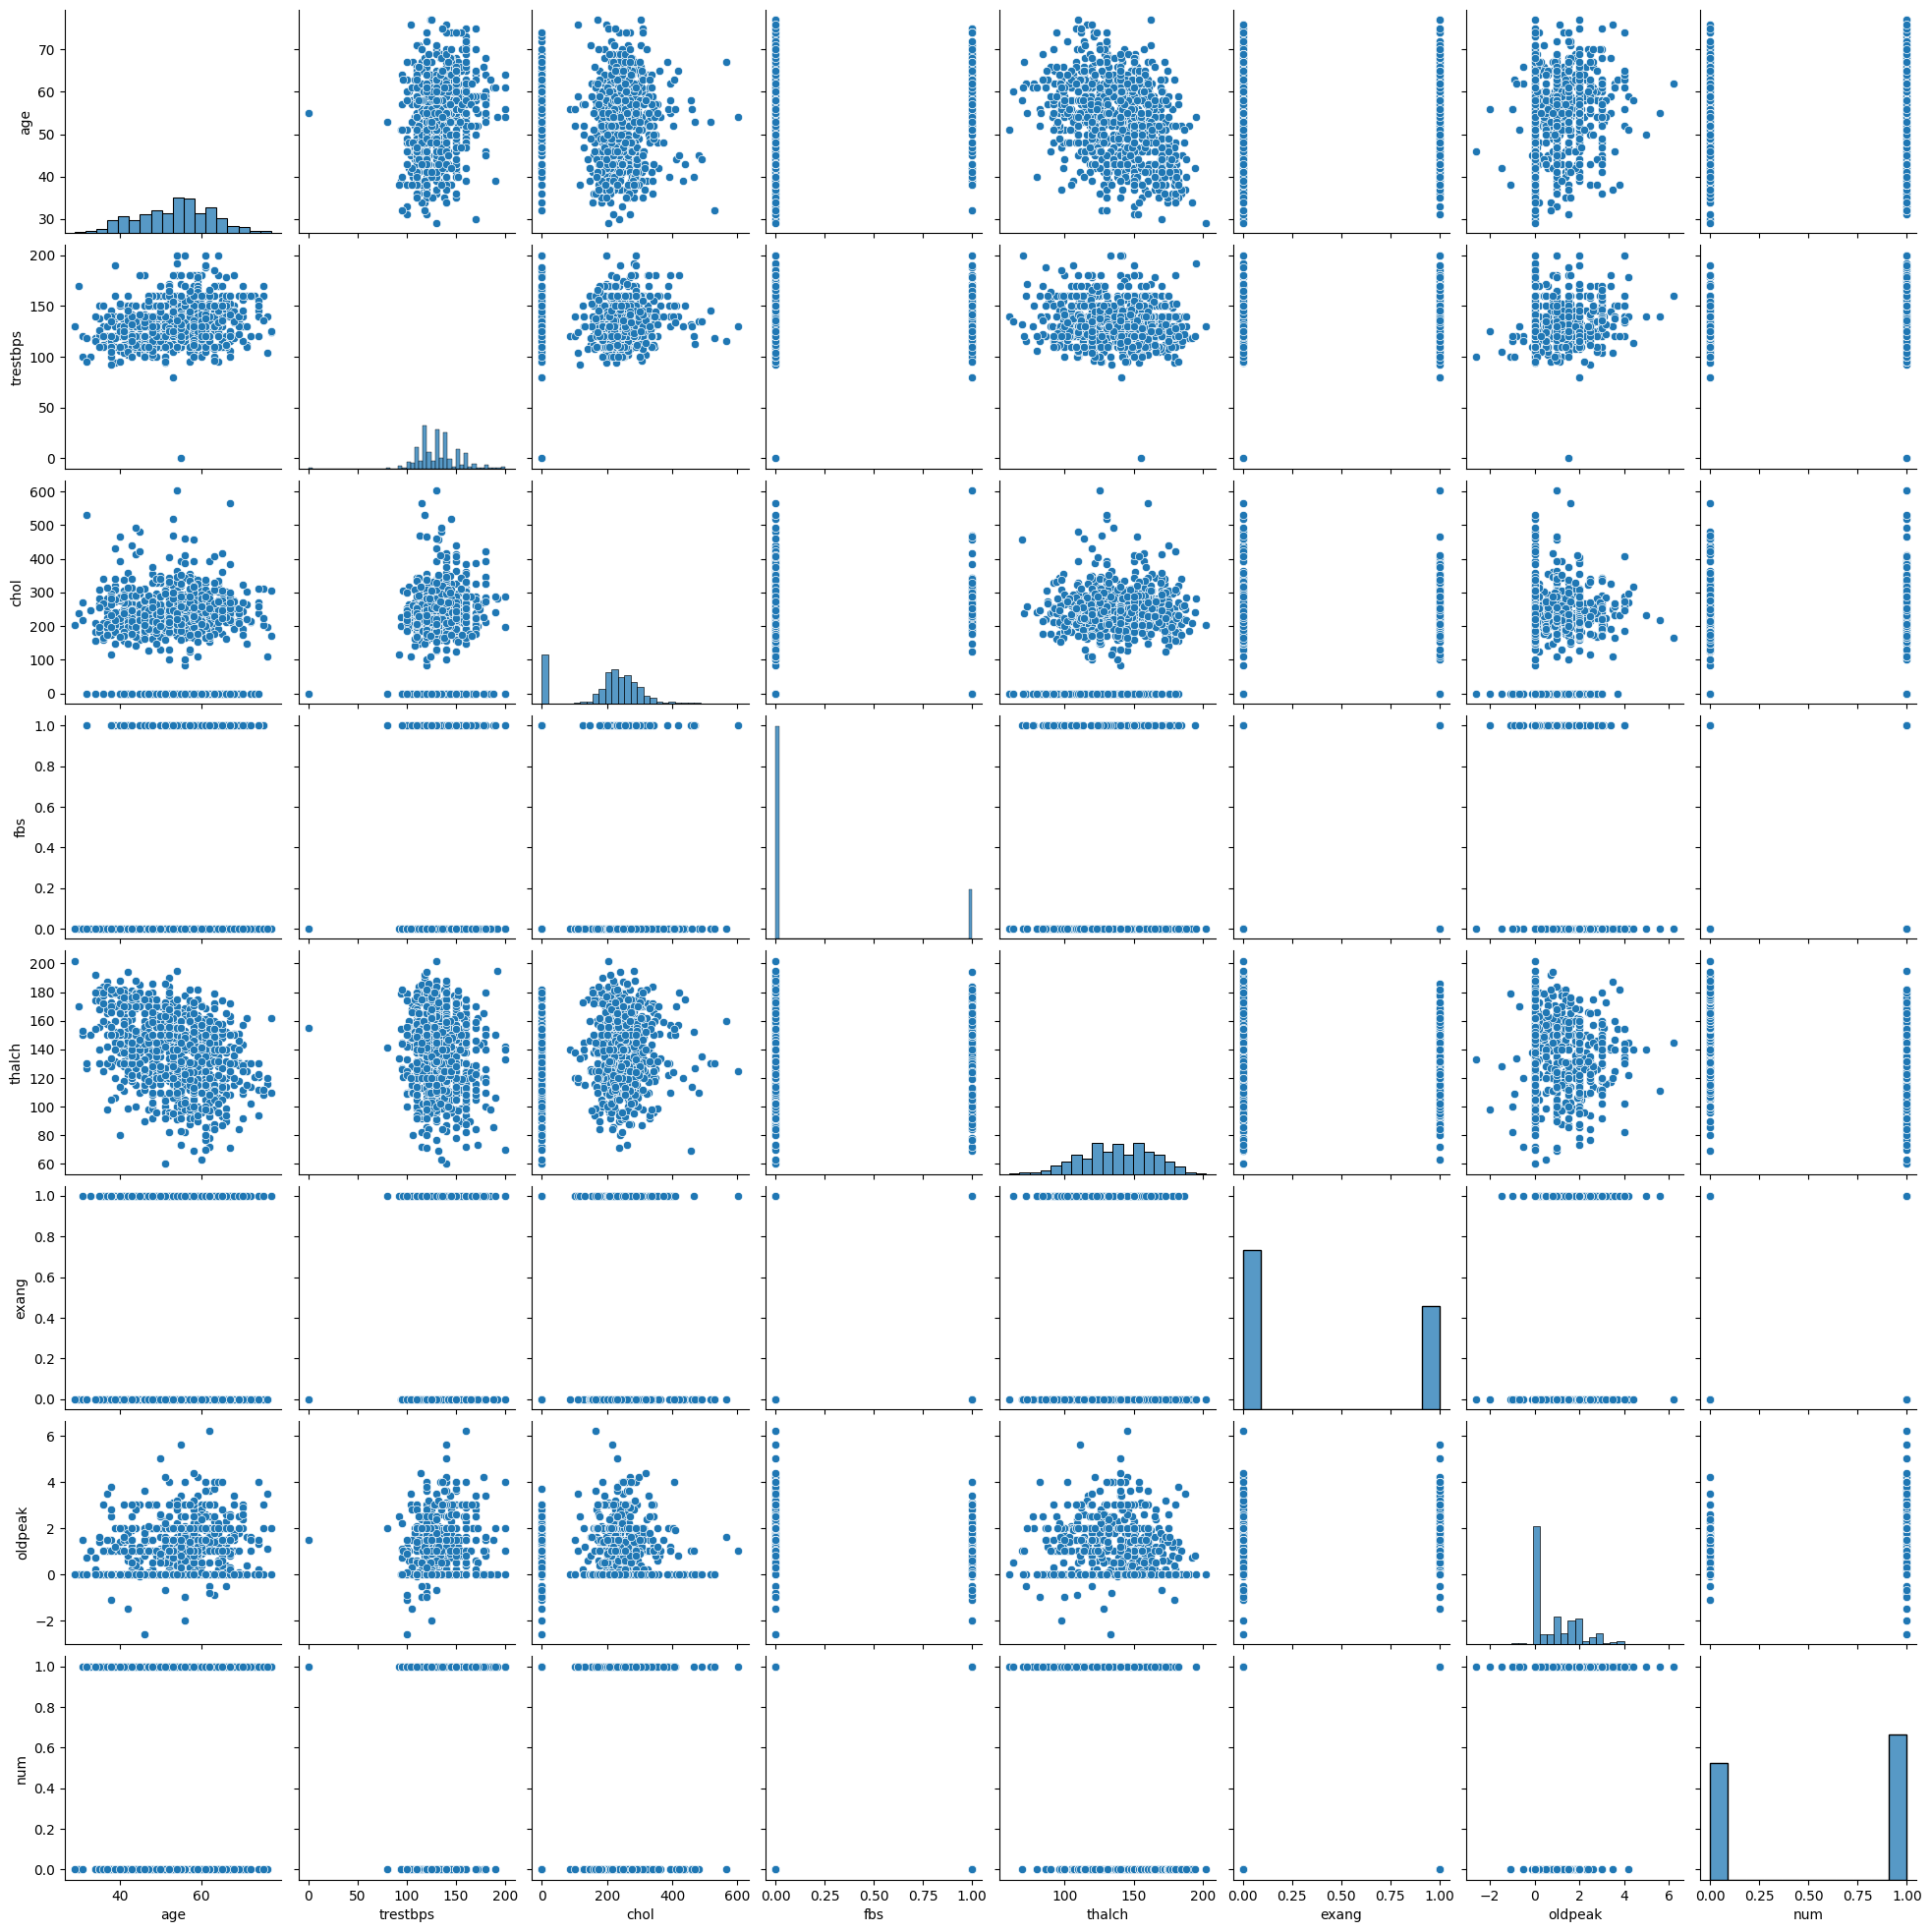

In [25]:
sns.pairplot(heart_df)

# Preprocessing the dataset

In [26]:
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

### Scaling the Numerical Features:

In [27]:
scaler = StandardScaler()

In [28]:
num_fet = ['trestbps','chol','thalch','oldpeak']

In [29]:
heart_df[num_fet] = scaler.fit_transform(heart_df[num_fet])
heart_df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,0.658540,0.273077,True,lv hypertrophy,0.499578,False,1.288614,downsloping,fixed defect,0
1,41,Male,atypical angina,0.137046,0.004404,False,normal,-0.203227,False,-0.814865,flat,fixed defect,0
2,57,Male,asymptomatic,0.397793,-0.094110,False,normal,0.421489,False,-0.449043,flat,fixed defect,0
3,52,Male,typical angina,-0.749492,-0.147845,False,lv hypertrophy,2.061367,False,-0.814865,flat,fixed defect,0
4,57,Male,asymptomatic,-1.166687,-0.013508,False,normal,-0.437495,True,0.556969,flat,fixed defect,0


#### Encoding Categorical Columns

In [30]:
heart_df_encoded = heart_df.copy()

In [31]:
# int - label encoder
label_encoder = preprocessing.LabelEncoder()

In [32]:
heart_df_encoded.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch',
       'exang', 'oldpeak', 'slope', 'thal', 'num'],
      dtype='object')

In [33]:
heart_df_encoded.nunique()

age          49
sex           2
cp            4
trestbps     63
chol        219
fbs           2
restecg       3
thalch      118
exang         2
oldpeak      53
slope         3
thal          3
num           2
dtype: int64

In [34]:
heart_df_encoded['sex']= label_encoder.fit_transform(heart_df_encoded['sex'])
heart_df_encoded['cp']= label_encoder.fit_transform(heart_df_encoded['cp'])
heart_df_encoded['fbs']= label_encoder.fit_transform(heart_df_encoded['fbs'])
heart_df_encoded['restecg']= label_encoder.fit_transform(heart_df_encoded['restecg'])
heart_df_encoded['exang']= label_encoder.fit_transform(heart_df_encoded['exang'])
heart_df_encoded['slope']= label_encoder.fit_transform(heart_df_encoded['slope'])
heart_df_encoded['thal']= label_encoder.fit_transform(heart_df_encoded['thal'])

In [35]:
heart_df_encoded.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,1,3,0.658540,0.273077,1,0,0.499578,0,1.288614,0,0,0
1,41,1,1,0.137046,0.004404,0,1,-0.203227,0,-0.814865,1,0,0
2,57,1,0,0.397793,-0.094110,0,1,0.421489,0,-0.449043,1,0,0
3,52,1,3,-0.749492,-0.147845,0,0,2.061367,0,-0.814865,1,0,0
4,57,1,0,-1.166687,-0.013508,0,1,-0.437495,1,0.556969,1,0,0


In [36]:
target_y = heart_df_encoded['num']

In [37]:
target_y

0      0
1      0
2      0
3      0
4      0
      ..
901    1
902    1
903    1
904    1
905    1
Name: num, Length: 844, dtype: int64

In [38]:
inde_x = heart_df_encoded.iloc[:, 0:10]

In [39]:
inde_x

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak
0,63,1,3,0.658540,0.273077,1,0,0.499578,0,1.288614
1,41,1,1,0.137046,0.004404,0,1,-0.203227,0,-0.814865
2,57,1,0,0.397793,-0.094110,0,1,0.421489,0,-0.449043
3,52,1,3,-0.749492,-0.147845,0,0,2.061367,0,-0.814865
4,57,1,0,-1.166687,-0.013508,0,1,-0.437495,1,0.556969
...,...,...,...,...,...,...,...,...,...,...
901,51,1,0,-1.166687,-1.813618,1,1,-1.765016,0,-0.814865
902,62,1,0,1.440780,0.461148,1,2,-1.140300,1,1.928803
903,53,1,0,-0.384447,-1.813618,0,1,-0.671764,0,0.556969
904,62,1,0,1.753676,-0.291137,0,2,-0.671764,1,1.928803


In [40]:
heart_df_encoded.num.value_counts()

num
1    467
0    377
Name: count, dtype: int64

In [41]:
# Splitting the dataset into test and train:
x_train,x_test,y_train,y_test = train_test_split(inde_x,target_y,test_size=0.25,random_state=99)

In [42]:
print(x_train.shape,x_test.shape,y_train.shape,y_test.shape)

(633, 10) (211, 10) (633,) (211,)


# Model Building

In [43]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix , roc_curve, auc

In [44]:
model = DecisionTreeClassifier(criterion='entropy',max_depth=5)

In [45]:
model.fit(x_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [46]:
plt.figure(figsize=(25,8),dpi=1000)
tree.plot_tree(model,
               feature_names=inde_x.columns,
               class_names=heart_df_encoded.num.value_counts().index.astype('str'),
               fontsize=10,filled=True, rounded=True)
plt.show()

In [47]:
pred = model.predict(x_test)
pd.Series(pred).value_counts()

1    120
0     91
Name: count, dtype: int64

In [48]:
pd.crosstab(y_test,pred)

col_0,0,1
num,,
0,71,24
1,20,96


In [49]:
confusion_matrix(y_test,pred)

array([[71, 24],
       [20, 96]])

In [50]:
np.mean(pred==y_test)

np.float64(0.7914691943127962)

In [51]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.78      0.75      0.76        95
           1       0.80      0.83      0.81       116

    accuracy                           0.79       211
   macro avg       0.79      0.79      0.79       211
weighted avg       0.79      0.79      0.79       211



In [52]:
fpr, tpr, thresholds = roc_curve(y_test,pred)
roc_auc = auc(fpr,tpr)

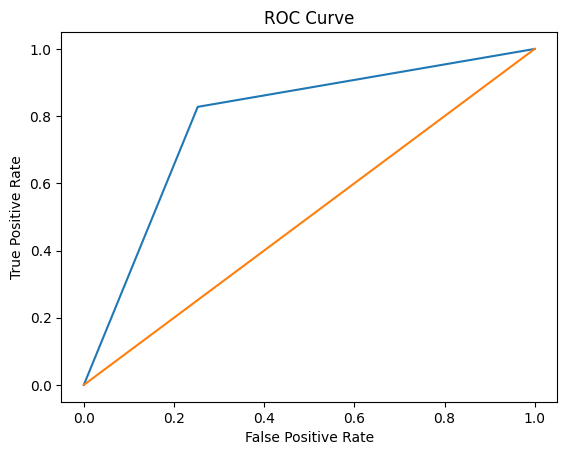

In [53]:
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.plot([0, 1], [0, 1])

## Decision Tree - Gini Criteria


In [54]:
model_gini = DecisionTreeClassifier(criterion='gini',max_depth=5)

In [55]:
model_gini.fit(x_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [56]:
pred_gini = model.predict(x_test)


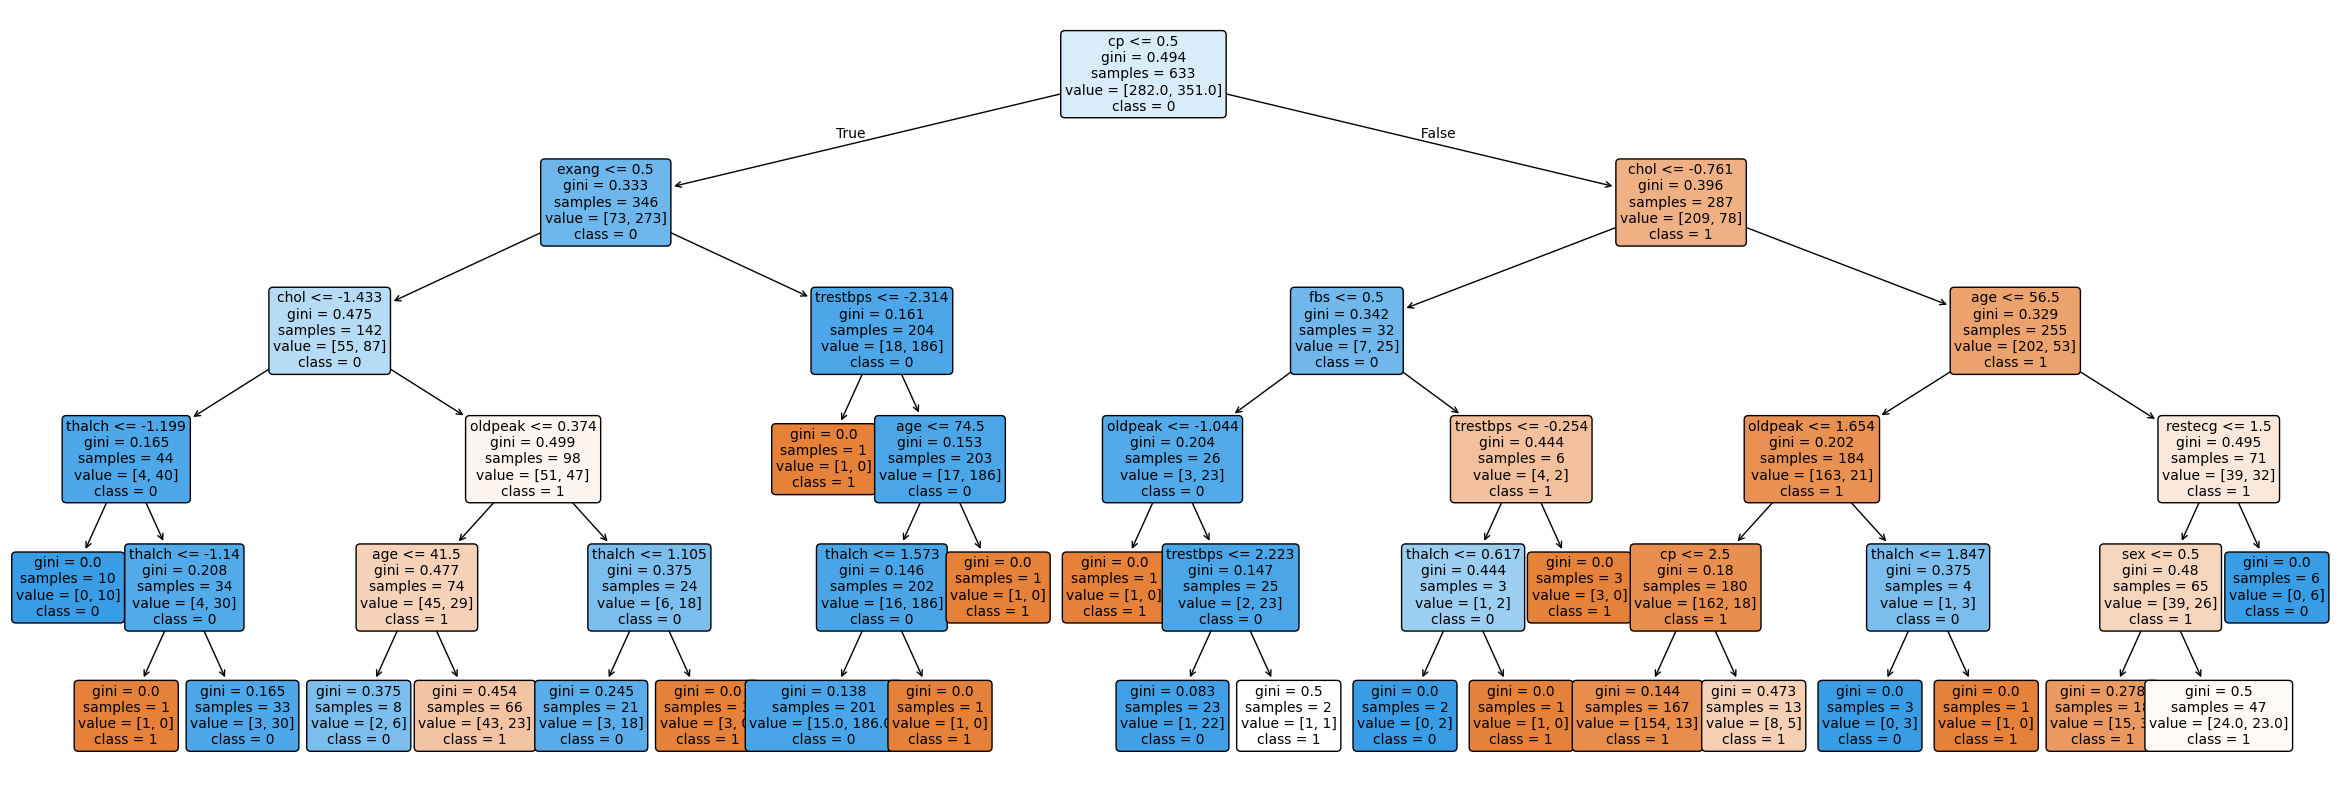

In [57]:
plt.figure(figsize=(30,10))
tree.plot_tree(model_gini,
               feature_names=inde_x.columns,
               class_names=heart_df_encoded.num.value_counts().index.astype('str'),
               fontsize=10,filled=True, rounded=True)
plt.show()

In [58]:
np.mean(pred_gini==y_test)

np.float64(0.7914691943127962)

In [59]:
print(classification_report(y_test,pred_gini))

              precision    recall  f1-score   support

           0       0.78      0.75      0.76        95
           1       0.80      0.83      0.81       116

    accuracy                           0.79       211
   macro avg       0.79      0.79      0.79       211
weighted avg       0.79      0.79      0.79       211



In [60]:
fpr, tpr, thresholds = roc_curve(y_test,pred_gini)
roc_auc = auc(fpr,tpr)

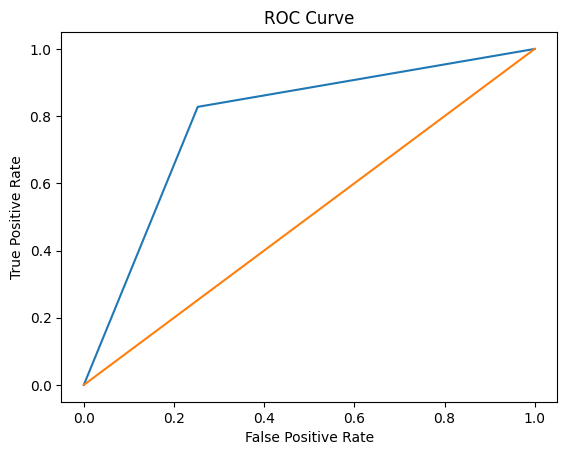

In [61]:
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.plot([0, 1], [0, 1])